# Stage 03: Feature Engineering

Create meaningful features from raw data to improve model predictions. Includes track characteristics, driver performance metrics, and team strength indicators.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.ticker import MaxNLocator

from src.data_pipeline import load_race_results, load_qualifying_results, load_circuits
from src.feature_engineering import (
    create_track_features,
    create_driver_features,
    create_team_features,
    build_full_feature_matrix,
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

SAVE_DIR = '../outputs/figures/'

# Load raw data
race_df = load_race_results()
qual_df = load_qualifying_results()
circuits_df = load_circuits()
print(f"Loaded: {len(race_df):,} race results, {len(qual_df):,} qualifying results, {len(circuits_df)} circuits")

Loaded: 4,626 race results, 4,610 qualifying results, 78 circuits


## 3.1 Track Characteristic Features

- Position variance (how much shuffling happens)
- DNF rate by circuit
- Top-3 grid conversion rate

In [2]:
track_features = create_track_features(race_df)
print(f"Track features: {track_features.shape}")
print(f"Columns: {list(track_features.columns)}\n")
track_features.sort_values('track_position_std', ascending=False).head(10)

Track features: (32, 7)
Columns: ['circuitId', 'track_position_std', 'track_avg_finish', 'track_dnf_rate', 'track_avg_position_gain', 'track_races_held', 'track_top3_conversion_rate']



,circuitId,track_position_std,track_avg_finish,track_dnf_rate,track_avg_position_gain,track_races_held,track_top3_conversion_rate
5,hockenheimring,6.133016,11.023810,0.214286,0.000000,4,0.583333
22,sepang,6.133016,11.023810,0.238095,-0.261905,4,0.909091
23,shanghai,5.987490,10.805556,0.125000,-0.138889,7,0.666667
12,marina_bay,5.941186,10.739130,0.217391,-0.217391,9,0.703704
27,suzuka,5.941186,10.739130,0.135870,-0.108696,9,0.777778
29,villeneuve,5.941186,10.739130,0.201087,-0.108696,9,0.814815
14,monaco,5.924613,10.715686,0.196078,-0.308824,10,0.800000
16,mugello,5.916080,10.500000,0.400000,0.000000,1,0.666667
17,nurburgring,5.916080,10.500000,0.250000,0.000000,1,0.666667
25,sochi,5.914133,10.699387,0.171779,-0.116564,8,0.750000


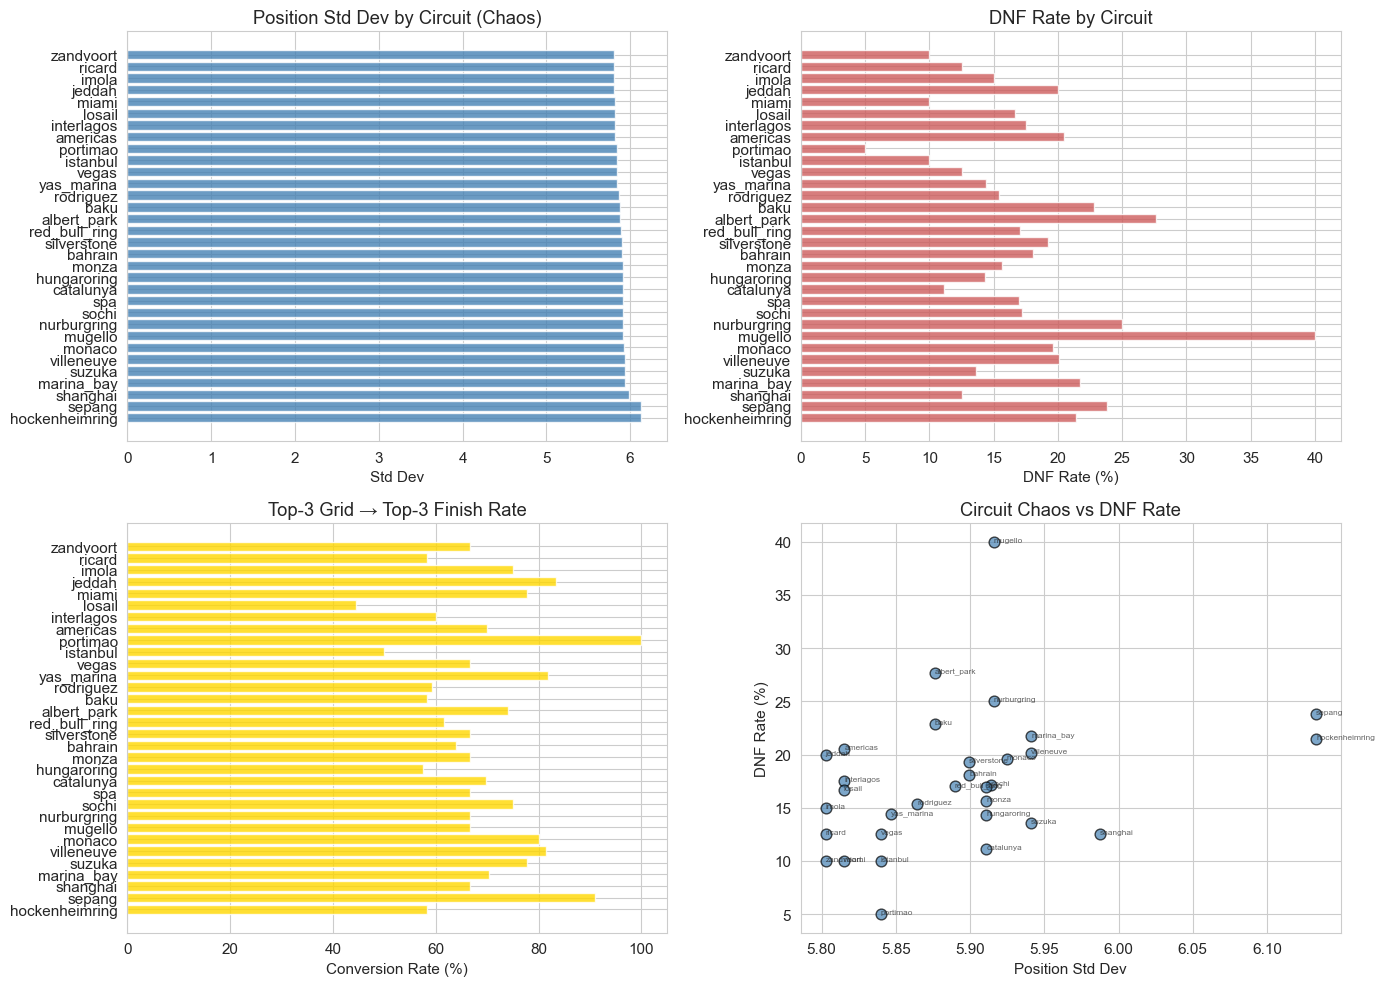

Saved track_features.csv (32 circuits)


In [3]:
# Visualize track features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

track_sorted = track_features.sort_values('track_position_std', ascending=False)

axes[0, 0].barh(track_sorted['circuitId'], track_sorted['track_position_std'], color='steelblue', alpha=0.8)
axes[0, 0].set_title('Position Std Dev by Circuit (Chaos)')
axes[0, 0].set_xlabel('Std Dev')

axes[0, 1].barh(track_sorted['circuitId'], track_sorted['track_dnf_rate'] * 100, color='indianred', alpha=0.8)
axes[0, 1].set_title('DNF Rate by Circuit')
axes[0, 1].set_xlabel('DNF Rate (%)')

axes[1, 0].barh(track_sorted['circuitId'], track_sorted['track_top3_conversion_rate'] * 100, color='gold', alpha=0.8)
axes[1, 0].set_title('Top-3 Grid \u2192 Top-3 Finish Rate')
axes[1, 0].set_xlabel('Conversion Rate (%)')

axes[1, 1].scatter(track_features['track_position_std'], track_features['track_dnf_rate'] * 100,
                    s=60, alpha=0.7, color='steelblue', edgecolors='black')
for _, row in track_features.iterrows():
    axes[1, 1].annotate(row['circuitId'], (row['track_position_std'], row['track_dnf_rate'] * 100),
                         fontsize=6, alpha=0.7)
axes[1, 1].set_xlabel('Position Std Dev')
axes[1, 1].set_ylabel('DNF Rate (%)')
axes[1, 1].set_title('Circuit Chaos vs DNF Rate')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}track_features.png', dpi=150, bbox_inches='tight')
plt.show()

track_features.to_csv('../data/features/track_features.csv', index=False)
print(f"Saved track_features.csv ({len(track_features)} circuits)")

## 3.2 Driver Performance Features

- Rolling average finish position (last 5 races)
- Rolling average points
- Consistency score (std dev of finishes)
- DNF rate, position gain tendency
- Career stats and circuit-specific history

In [4]:
driver_df = create_driver_features(race_df, qual_df, window=5)
print(f"Driver features: {driver_df.shape}")
print(f"Columns: {list(driver_df.columns)}\n")
print(f"NaN counts per feature:")
print(driver_df[[c for c in driver_df.columns if c.startswith('driver_')]].isnull().sum())
print(f"\nSample \u2014 Hamilton's recent features:")
driver_df[driver_df['driverId'] == 'hamilton'].tail(5)

Driver features: (4626, 20)
Columns: ['season', 'round', 'driverId', 'driverCode', 'circuitId', 'constructorId', 'constructorName', 'grid', 'position', 'points', 'driver_rolling_position', 'driver_rolling_points', 'driver_consistency', 'driver_rolling_dnf_rate', 'driver_avg_position_gain', 'driver_career_races', 'driver_career_avg_position', 'driver_career_wins', 'driver_circuit_avg_position', 'qualifyingPosition']

NaN counts per feature:
driver_rolling_position          59
driver_rolling_points            59
driver_consistency              114
driver_rolling_dnf_rate          59
driver_avg_position_gain         59
driver_career_races               0
driver_career_avg_position       59
driver_career_wins               59
driver_circuit_avg_position    1268
dtype: int64

Sample — Hamilton's recent features:


,season,round,driverId,driverCode,circuitId,constructorId,constructorName,grid,position,points,driver_rolling_position,driver_rolling_points,driver_consistency,driver_rolling_dnf_rate,driver_avg_position_gain,driver_career_races,driver_career_avg_position,driver_career_wins,driver_circuit_avg_position,qualifyingPosition
1357,2024,24,hamilton,HAM,yas_marina,mercedes,Mercedes,16,4,12.0,9.6,6.2,7.127412,0.2,1.0,227,3.991150,83.0,4.0,18.0
1358,2021,13,hamilton,HAM,zandvoort,mercedes,Mercedes,2,2,19.0,2.4,16.3,1.140175,0.0,0.0,150,2.926174,77.0,NaN,2.0
1359,2022,15,hamilton,HAM,zandvoort,mercedes,Mercedes,4,4,12.0,6.0,13.6,7.842194,0.2,-0.4,174,3.213873,81.0,2.0,4.0
1360,2023,13,hamilton,HAM,zandvoort,mercedes,Mercedes,13,6,8.0,4.4,11.8,2.073644,0.0,-0.6,194,3.393782,81.0,3.0,13.0
1361,2024,15,hamilton,HAM,zandvoort,mercedes,Mercedes,14,8,4.0,2.4,18.4,1.341641,0.0,1.2,218,3.806452,83.0,4.0,11.0


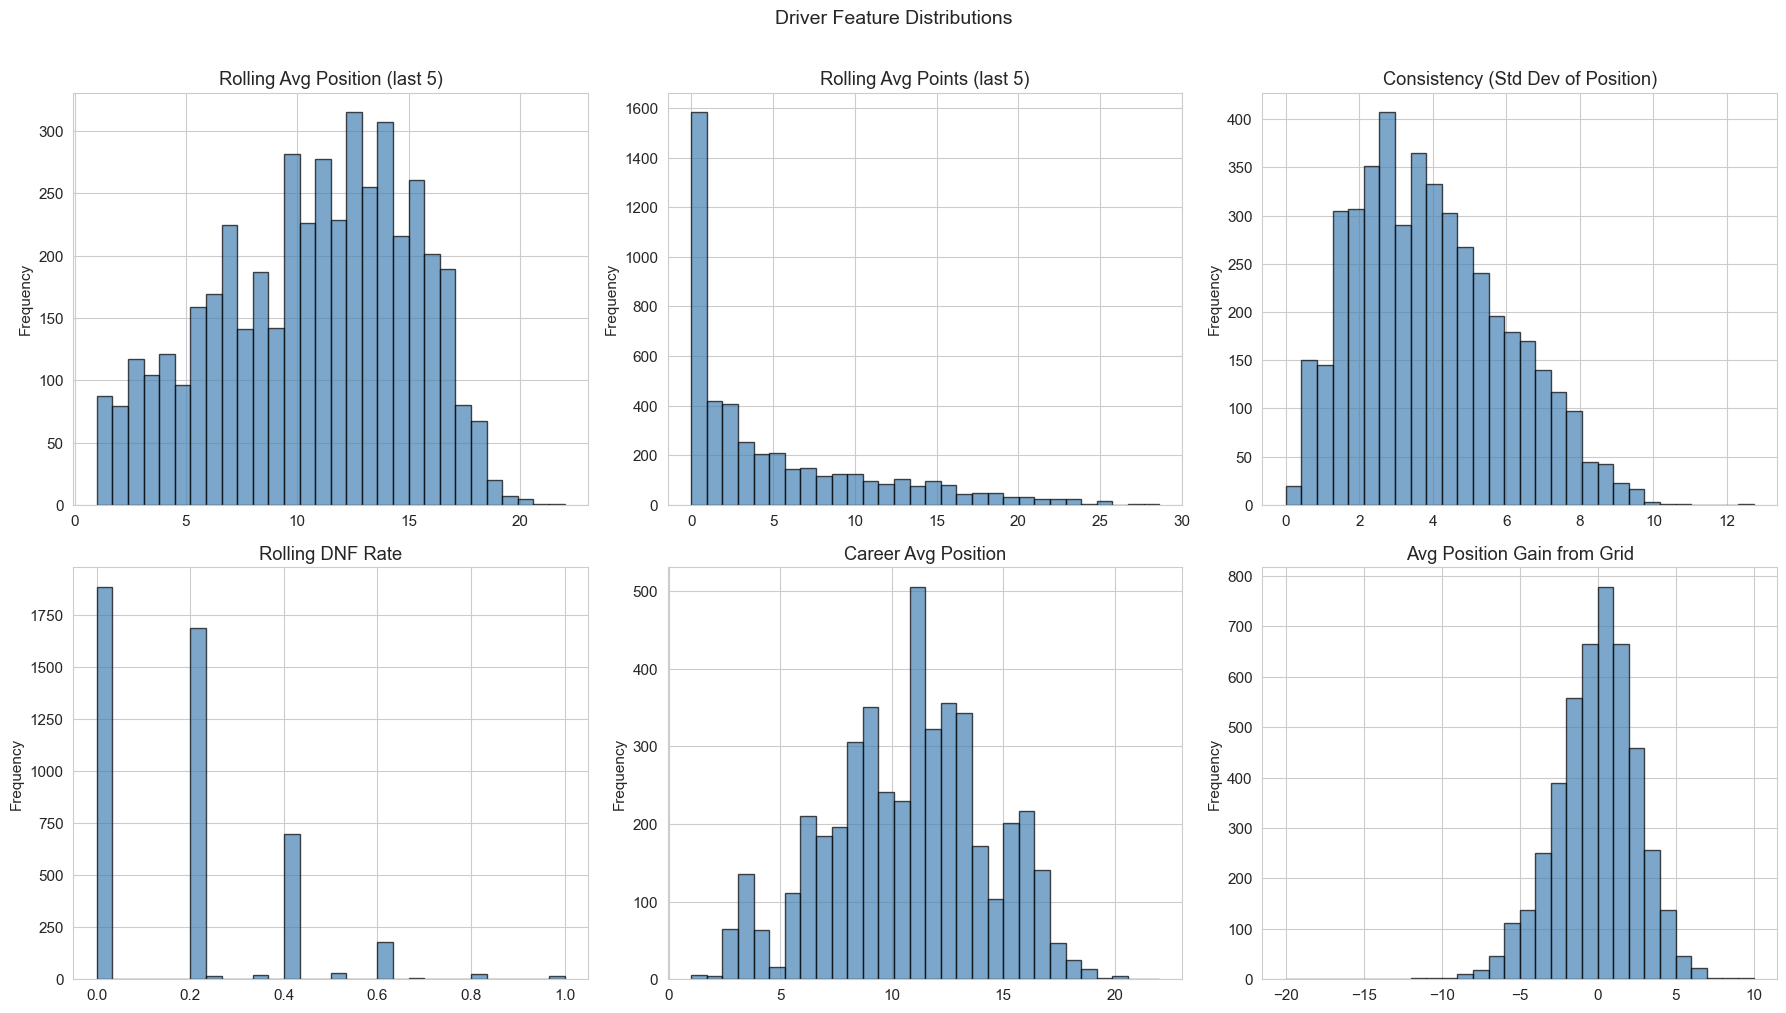

Saved driver_features.csv (4,626 rows)


In [5]:
# Visualize driver feature distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

driver_feat_cols = [
    ('driver_rolling_position', 'Rolling Avg Position (last 5)'),
    ('driver_rolling_points', 'Rolling Avg Points (last 5)'),
    ('driver_consistency', 'Consistency (Std Dev of Position)'),
    ('driver_rolling_dnf_rate', 'Rolling DNF Rate'),
    ('driver_career_avg_position', 'Career Avg Position'),
    ('driver_avg_position_gain', 'Avg Position Gain from Grid'),
]

for ax, (col, title) in zip(axes.flat, driver_feat_cols):
    data = driver_df[col].dropna()
    ax.hist(data, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_title(title)
    ax.set_ylabel('Frequency')

plt.suptitle('Driver Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}driver_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

driver_df.to_csv('../data/features/driver_features.csv', index=False)
print(f"Saved driver_features.csv ({len(driver_df):,} rows)")

## 3.3 Team/Constructor Features

- Team rolling points and avg position
- Reliability score (1 - DNF rate)
- Development trajectory (points trend slope)

In [6]:
team_df = create_team_features(race_df, window=5)
print(f"Team features: {team_df.shape}")
print(f"Columns: {list(team_df.columns)}\n")
print(f"NaN counts:")
print(team_df.isnull().sum())
print(f"\nSample \u2014 Red Bull's recent features:")
team_df[team_df['constructorId'] == 'red_bull'].tail(5)

Team features: (2314, 8)
Columns: ['season', 'round', 'constructorId', 'team_rolling_points', 'team_rolling_position', 'team_rolling_best_position', 'team_reliability', 'team_development']

NaN counts:
season                          0
round                           0
constructorId                   0
team_rolling_points            20
team_rolling_position          20
team_rolling_best_position     20
team_reliability               20
team_development              100
dtype: int64

Sample — Red Bull's recent features:


,season,round,constructorId,team_rolling_points,team_rolling_position,team_rolling_best_position,team_reliability,team_development
1736,2024,20,red_bull,17.6,6.6,3.6,0.9,-0.3
1737,2024,21,red_bull,14.0,8.1,4.4,0.9,0.3
1738,2024,22,red_bull,16.8,7.9,3.4,0.9,2.1
1739,2024,23,red_bull,17.0,7.2,3.4,1.0,-1.1
1740,2024,24,red_bull,18.2,7.8,3.2,0.9,1.1


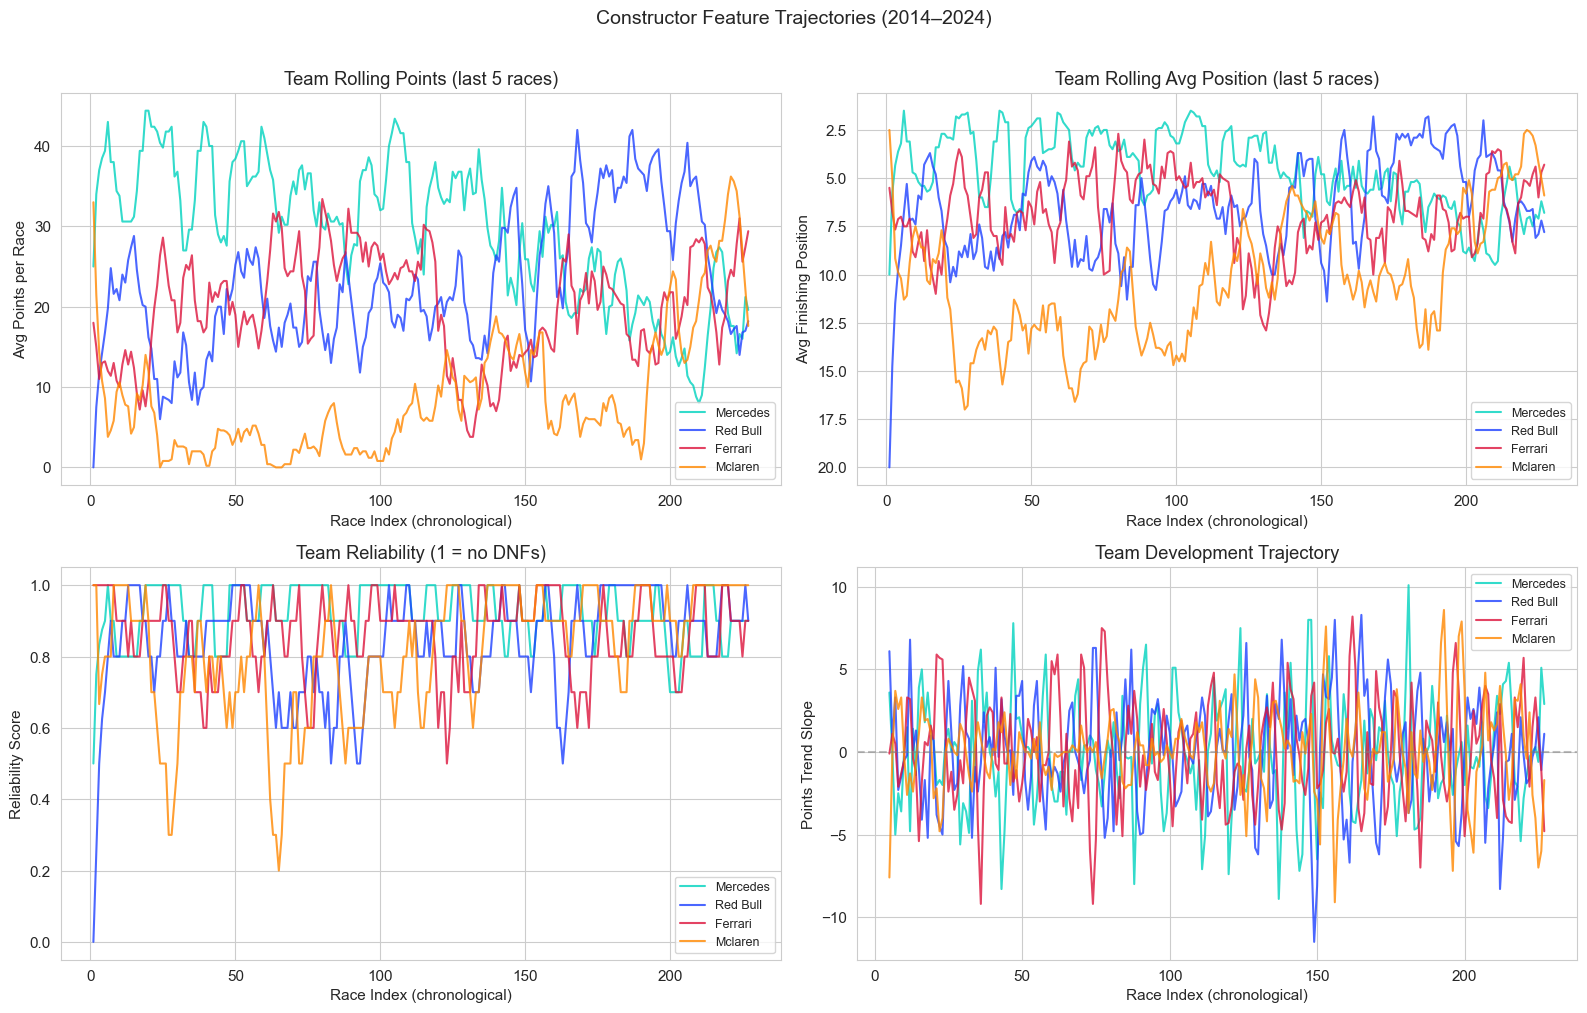

Saved team_features.csv (2,314 rows)


In [7]:
# Visualize team strength trajectories for top teams
top_teams = ['mercedes', 'red_bull', 'ferrari', 'mclaren']
team_colors = {'mercedes': '#00D2BE', 'red_bull': '#1E41FF', 'ferrari': '#DC143C', 'mclaren': '#FF8700'}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for team in top_teams:
    d = team_df[team_df['constructorId'] == team].copy()
    d['race_idx'] = range(len(d))
    color = team_colors[team]

    axes[0, 0].plot(d['race_idx'], d['team_rolling_points'], label=team.replace('_', ' ').title(),
                     color=color, linewidth=1.5, alpha=0.8)
    axes[0, 1].plot(d['race_idx'], d['team_rolling_position'], label=team.replace('_', ' ').title(),
                     color=color, linewidth=1.5, alpha=0.8)
    axes[1, 0].plot(d['race_idx'], d['team_reliability'], label=team.replace('_', ' ').title(),
                     color=color, linewidth=1.5, alpha=0.8)
    axes[1, 1].plot(d['race_idx'], d['team_development'], label=team.replace('_', ' ').title(),
                     color=color, linewidth=1.5, alpha=0.8)

axes[0, 0].set_title('Team Rolling Points (last 5 races)')
axes[0, 0].set_ylabel('Avg Points per Race')
axes[0, 0].legend(fontsize=9)

axes[0, 1].set_title('Team Rolling Avg Position (last 5 races)')
axes[0, 1].set_ylabel('Avg Finishing Position')
axes[0, 1].invert_yaxis()
axes[0, 1].legend(fontsize=9)

axes[1, 0].set_title('Team Reliability (1 = no DNFs)')
axes[1, 0].set_ylabel('Reliability Score')
axes[1, 0].legend(fontsize=9)

axes[1, 1].set_title('Team Development Trajectory')
axes[1, 1].set_ylabel('Points Trend Slope')
axes[1, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].legend(fontsize=9)

for ax in axes.flat:
    ax.set_xlabel('Race Index (chronological)')

plt.suptitle('Constructor Feature Trajectories (2014\u20132024)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}team_features.png', dpi=150, bbox_inches='tight')
plt.show()

team_df.to_csv('../data/features/team_features.csv', index=False)
print(f"Saved team_features.csv ({len(team_df):,} rows)")

## 3.4 PCA on Track Features

Reduce dimensionality of track characteristics to identify underlying circuit archetypes.

PCA explained variance ratio: [0.44577291 0.21410466 0.20898406]
Cumulative variance explained: [0.44577291 0.65987758 0.86886163]

PC1 + PC2 explain 66.0% of variance

PCA Loadings:
                              PC1    PC2    PC3
track_position_std          0.631 -0.265 -0.099
track_avg_finish            0.591 -0.344 -0.253
track_dnf_rate              0.323  0.133  0.719
track_avg_position_gain     0.336  0.623  0.261
track_top3_conversion_rate  0.186  0.636 -0.584


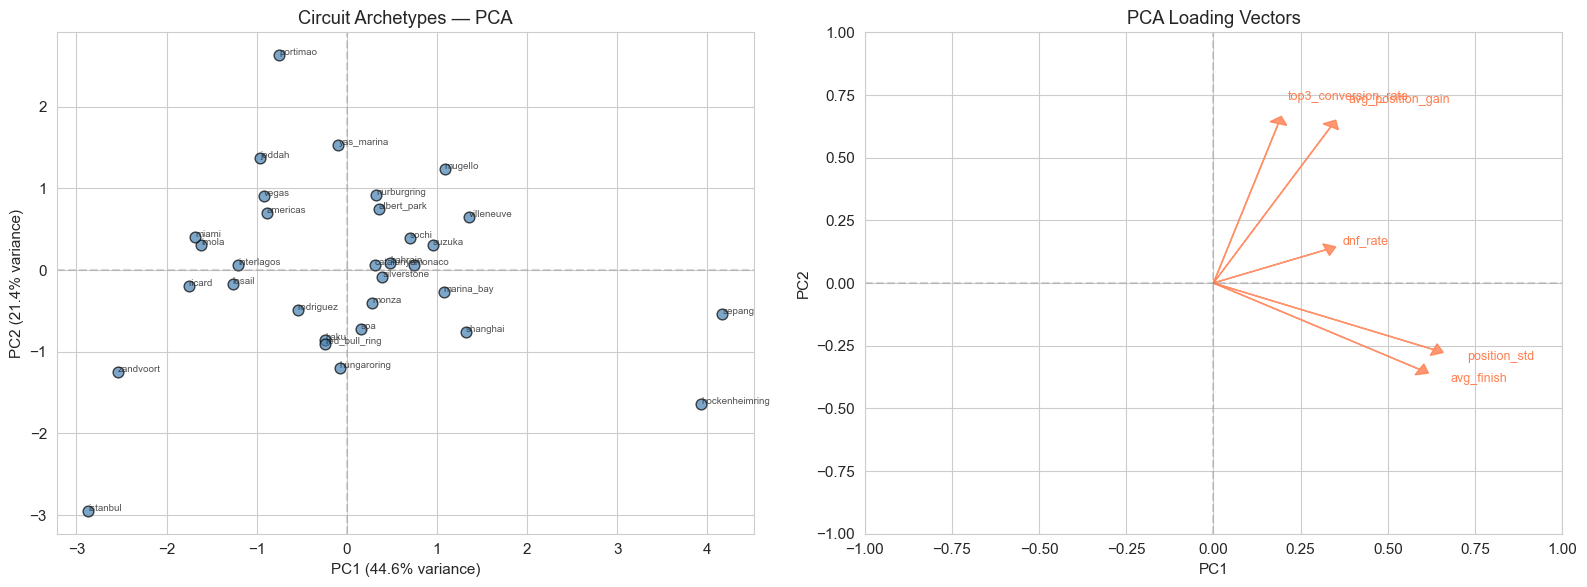

In [8]:
# PCA on track features to identify circuit archetypes
track_numeric = track_features.set_index('circuitId')[
    ['track_position_std', 'track_avg_finish', 'track_dnf_rate',
     'track_avg_position_gain', 'track_top3_conversion_rate']
]

scaler = StandardScaler()
track_scaled = scaler.fit_transform(track_numeric)

pca = PCA(n_components=3)
track_pca = pca.fit_transform(track_scaled)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Cumulative variance explained: {pca.explained_variance_ratio_.cumsum()}")
print(f"\nPC1 + PC2 explain {pca.explained_variance_ratio_[:2].sum():.1%} of variance")

# Component loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=track_numeric.columns
)
print(f"\nPCA Loadings:")
print(loadings.round(3))

# Scatter: PC1 vs PC2 with circuit labels
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(track_pca[:, 0], track_pca[:, 1], s=60, alpha=0.7, color='steelblue', edgecolors='black')
for i, circuit in enumerate(track_numeric.index):
    axes[0].annotate(circuit, (track_pca[i, 0], track_pca[i, 1]), fontsize=7, alpha=0.8)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[0].set_title('Circuit Archetypes \u2014 PCA')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.3)

# Loadings biplot
for i, feature in enumerate(track_numeric.columns):
    axes[1].arrow(0, 0, loadings.iloc[i, 0], loadings.iloc[i, 1],
                   head_width=0.05, head_length=0.03, fc='coral', ec='coral', alpha=0.8)
    axes[1].text(loadings.iloc[i, 0] * 1.15, loadings.iloc[i, 1] * 1.15,
                  feature.replace('track_', ''), fontsize=9, color='coral')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('PCA Loading Vectors')
axes[1].set_xlim(-1, 1)
axes[1].set_ylim(-1, 1)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}track_pca.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.5 Build Full Feature Matrix

In [9]:
# Build the full merged feature matrix
print("Building full feature matrix...")
features = build_full_feature_matrix(race_df, qual_df, circuits_df, window=5)
print(f"\nFull feature matrix: {features.shape}")
print(f"\nFeature columns ({len([c for c in features.columns if c.startswith(('driver_', 'team_', 'track_', 'qualifying'))])} engineered features):")
for col in sorted(features.columns):
    if col.startswith(('driver_', 'team_', 'track_', 'qualifying')):
        print(f"  {col}: {features[col].isnull().sum()} NaN, range [{features[col].min():.2f}, {features[col].max():.2f}]")

# Save full feature matrix
features.to_csv('../data/features/full_feature_matrix.csv', index=False)
print(f"\nSaved full_feature_matrix.csv ({len(features):,} rows x {features.shape[1]} cols)")

Building full feature matrix...



Full feature matrix: (4626, 31)

Feature columns (21 engineered features):
  driver_avg_position_gain: 0 NaN, range [-20.00, 10.00]
  driver_career_avg_position: 0 NaN, range [1.00, 22.00]
  driver_career_races: 0 NaN, range [1.00, 228.00]
  driver_career_wins: 0 NaN, range [0.00, 83.00]
  driver_circuit_avg_position: 0 NaN, range [1.00, 22.00]
  driver_consistency: 0 NaN, range [0.00, 12.73]
  driver_rolling_dnf_rate: 0 NaN, range [0.00, 1.00]
  driver_rolling_points: 0 NaN, range [0.00, 28.60]
  driver_rolling_position: 0 NaN, range [1.00, 22.00]
  qualifyingPosition: 16 NaN, range [1.00, 22.00]
  team_development: 0 NaN, range [-11.50, 10.50]
  team_reliability: 0 NaN, range [0.00, 1.00]
  team_rolling_best_position: 0 NaN, range [1.00, 18.00]
  team_rolling_points: 0 NaN, range [0.00, 44.40]
  team_rolling_position: 0 NaN, range [1.50, 20.00]
  track_avg_finish: 0 NaN, range [10.50, 11.02]
  track_avg_position_gain: 0 NaN, range [-0.95, 0.00]
  track_dnf_rate: 0 NaN, range [0.05, 

## 3.6 Feature Correlation Analysis

Examine how engineered features correlate with the target variable (finishing position) and with each other.

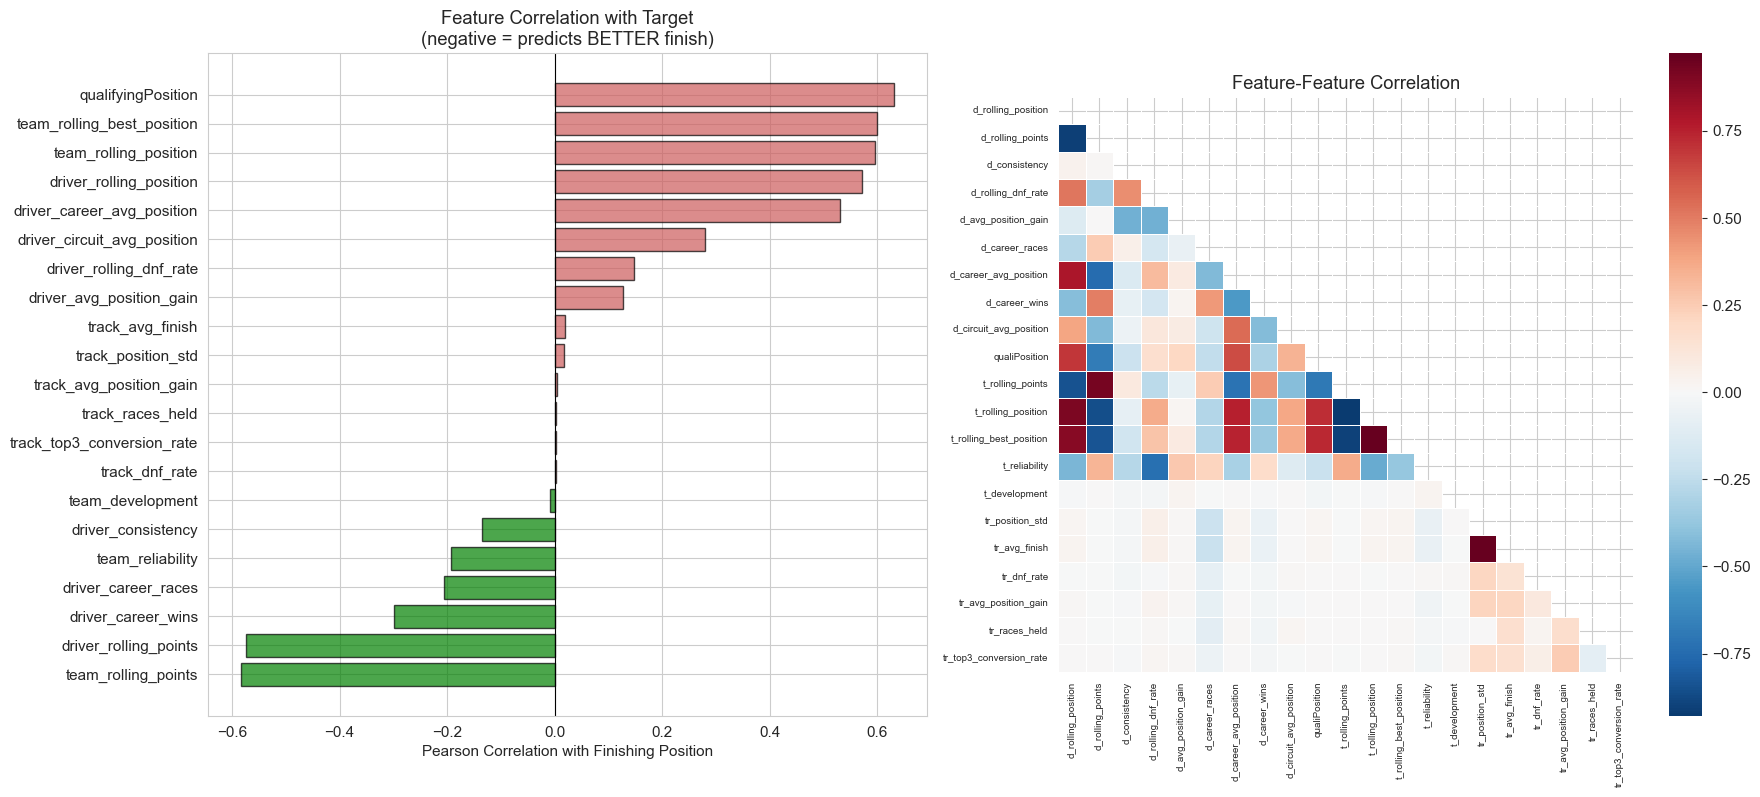

Top 5 features most correlated with finishing position (absolute):
  qualifyingPosition: r=0.632 (lower position)
  team_rolling_best_position: r=0.601 (lower position)
  team_rolling_position: r=0.595 (lower position)
  team_rolling_points: r=-0.584 (higher position)
  driver_rolling_points: r=-0.573 (higher position)


In [10]:
# Correlation with target (position)
feature_cols = [c for c in features.columns if c.startswith(('driver_', 'team_', 'track_', 'qualifying'))]
corr_with_target = features[feature_cols + ['position']].corr()['position'].drop('position').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Bar chart: correlation with position
colors = ['green' if x < 0 else 'indianred' for x in corr_with_target]
axes[0].barh(corr_with_target.index, corr_with_target.values, color=colors, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Pearson Correlation with Finishing Position')
axes[0].set_title('Feature Correlation with Target\n(negative = predicts BETTER finish)')
axes[0].axvline(x=0, color='black', linewidth=0.8)

# Heatmap: feature-feature correlation
corr_matrix = features[feature_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0, ax=axes[1],
            square=True, linewidths=0.5,
            xticklabels=[c.replace('driver_', 'd_').replace('team_', 't_').replace('track_', 'tr_').replace('qualifying', 'quali')
                          for c in feature_cols],
            yticklabels=[c.replace('driver_', 'd_').replace('team_', 't_').replace('track_', 'tr_').replace('qualifying', 'quali')
                          for c in feature_cols])
axes[1].set_title('Feature-Feature Correlation')
axes[1].tick_params(axis='both', labelsize=7)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 features most correlated with finishing position (absolute):")
for feat, corr in corr_with_target.abs().sort_values(ascending=False).head(5).items():
    direction = "lower position" if corr_with_target[feat] > 0 else "higher position"
    print(f"  {feat}: r={corr_with_target[feat]:.3f} ({direction})")